In [93]:
from sklearn.datasets import load_iris

In [94]:
X,y = load_iris(return_X_y=True)

In [95]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [96]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=10)

In [97]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()

In [98]:
model.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


In [99]:
y_pred = model.predict(X_test)
print(y_pred)

[1 2 0 1 0 1 1 1 0 1 1 2 1 0 0 2 1 0 0 0 2 2 2 0 1 0 1 1 1 2 1 1 2 2 2 0 2
 2 2 2 0 0 1 0 1]


In [100]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        17
           2       1.00      1.00      1.00        14

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



Text(50.722222222222214, 0.5, 'Actual')

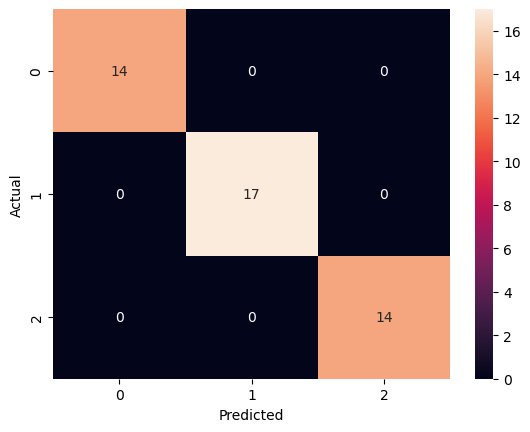

In [102]:
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [103]:
df = sns.load_dataset("tips")

In [104]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [105]:
df.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [107]:
df['day'].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [108]:
df['time'].value_counts()

time
Dinner    176
Lunch      68
Name: count, dtype: int64

In [109]:
df.drop(columns=['size'],inplace=True)

In [110]:
df.head()

,total_bill,tip,sex,smoker,day,time
0,16.99,1.01,Female,No,Sun,Dinner
1,10.34,1.66,Male,No,Sun,Dinner
2,21.01,3.50,Male,No,Sun,Dinner
3,23.68,3.31,Male,No,Sun,Dinner
4,24.59,3.61,Female,No,Sun,Dinner


In [111]:
import pandas as pd

In [112]:
X = df.drop(columns=['time'],axis=1)
y = pd.DataFrame(df['time'])

In [113]:
X.head()

,total_bill,tip,sex,smoker,day
0,16.99,1.01,Female,No,Sun
1,10.34,1.66,Male,No,Sun
2,21.01,3.50,Male,No,Sun
3,23.68,3.31,Male,No,Sun
4,24.59,3.61,Female,No,Sun


In [114]:
y.head()

,time
0,Dinner
1,Dinner
2,Dinner
3,Dinner
4,Dinner


In [115]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=15)

In [116]:
# Now perform label encoding for binary categorical features.
from sklearn.preprocessing import LabelEncoder
le1 = LabelEncoder()
le2 = LabelEncoder()
le3 = LabelEncoder()

In [117]:
X_train['sex'] = le1.fit_transform(X_train['sex'])
X_train['smoker'] = le2.fit_transform(X_train['smoker'])
X_test['sex'] = le1.transform(X_test['sex'])
X_test['smoker'] = le2.transform(X_test['smoker'])

In [118]:
y_train.head()

,time
136,Lunch
47,Dinner
129,Lunch
148,Lunch
95,Dinner


In [119]:
# Now perform one hot encoding for the 'day' feature.
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
ct = ColumnTransformer(transformers=[('onehot',OneHotEncoder(drop='first'),['day'])],remainder='passthrough')

In [120]:
# Now perform one hot encoding for the 'day' feature.
X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

In [121]:
X_train

array([[0.  , 0.  , 1.  , ..., 2.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , ..., 6.  , 1.  , 0.  ],
       [0.  , 0.  , 1.  , ..., 2.18, 1.  , 0.  ],
       ...,
       [0.  , 0.  , 1.  , ..., 2.  , 0.  , 0.  ],
       [0.  , 0.  , 1.  , ..., 3.5 , 0.  , 0.  ],
       [0.  , 0.  , 1.  , ..., 4.  , 1.  , 1.  ]], shape=(170, 7))

In [122]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X_train,y_train)

c:\Users\akula\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,priors,None
,var_smoothing,1e-09


In [123]:
y_pred = model.predict(X_test)

0.918918918918919
              precision    recall  f1-score   support

      Dinner       1.00      0.88      0.94        52
       Lunch       0.79      1.00      0.88        22

    accuracy                           0.92        74
   macro avg       0.89      0.94      0.91        74
weighted avg       0.94      0.92      0.92        74



Text(50.722222222222214, 0.5, 'Actual')

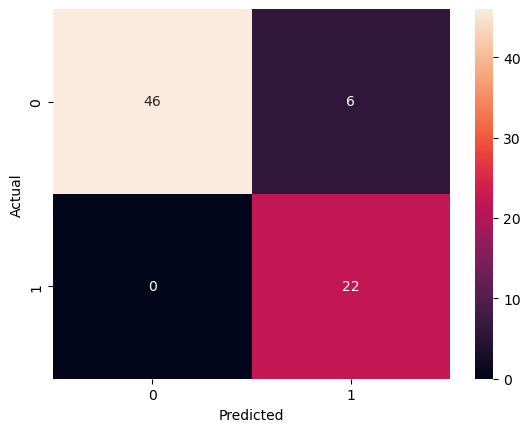

In [124]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
